# **Mini-Project #2: Analysis of Nigerian Internally Displaced Persons Sites**

---

**Author:** Engin Samet Dede  


# **Identifying Vulnerable Populations in Nigerian IDP Sites**

## **Context**

Internally Displaced Persons (IDP) sites in northern Nigeria host very different populations. Some are dominated by young adults and working-age families; others concentrate groups whose needs are easy to under-serve in a generic camp response — infants, the elderly, female-headed households.

For humanitarian planners, treating every site the same wastes resources and leaves the most fragile people underserved. The first step toward targeted aid is knowing **which sites concentrate vulnerable demographics, and where those sites are**.

## **Main question**

> **Is there a "weak", vulnerable sub-population we should care for specifically — and if so, is it geographically concentrated?**

Concretely, we want to answer:

1. Do IDP sites fall into distinct demographic profiles based on age/sex composition?
2. Does any profile look like a vulnerable group requiring tailored support?
3. Is that group spread across the country, or concentrated in one zone?

The rest of the notebook tests this hypothesis with compositional clustering (CLR + K-Means) and a chi-square test of geographic association.


## **Setup**


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy import stats

plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})
PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#3B8132']

AGE_COLS = [
    'INFANTS MALE', 'INFANTS FEMALE',
    'CHILDREN MALE', 'CHILDREN FEMALE',
    'YOUTH MALE', 'YOUTH FEMALE',
    'ADULT MALE', 'ADULT FEMALE',
    'ELDERLY MALE', 'ELDERLY FEMALE',
]

## **Load and Clean the Data**

**TODO:**
1. Load `data.xlsx` into a DataFrame.
2. Drop any spurious `Unnamed:` columns that Excel sometimes adds.
3. Fix three known data-entry bugs:
   - `STATE` value `"KADUNNA"` should be `"KADUNA"`.
   - Site `BO_S002` has a missing/wrong `LATITUDE` — set it to `13.018227`.
   - Site `AD_S002` has a missing/wrong `LONGITUDE` — set it to `12.31593`.
4. Coerce all ten age-group columns to numeric (invalid entries become `NaN`).
5. Drop rows where any age column is missing.
6. Sanity-check that the row-wise sum of age columns matches `TOTAL NUMBER OF IDPS`
   to within ±100 — drop rows that fail this check.## **Load and Clean the Data**

**Steps:**

I wanted to observe and explain this step in detail:

1. First, read in the file `20161019-sample-data.xlsx` as a DataFrame.
2. Remove any unwanted `Unnamed:` columns that Excel may add.
3. Fix three known data-entry bugs:
   - `STATE` value `"KADUNNA"` → `"KADUNA"`.
   - Site `BO_S002` missing `LATITUDE` → set to `13.018227`.
   - Site `AD_S002` missing `LONGITUDE` → set to `12.31593`.
4. Force all ten age-group columns to numeric (where they are not, they will be NaN).
5. Remove rows if any age column is null.
6. Age columns should sum to within + or - 100 of the TOTAL NUMBER OF IDPS at the row level.

In [6]:
df = pd.read_excel('/content/drive/MyDrive/20161019-sample-data.xlsx')
df = df.drop(columns=[c for c in df.columns if str(c).startswith('Unnamed')])

# Fix data-entry bugs
df['STATE'] = df['STATE'].replace({'KADUNNA': 'KADUNA'})
df.loc[df['SITE ID'] == 'BO_S002', 'LATITUDE']  = 13.018227
df.loc[df['SITE ID'] == 'AD_S002', 'LONGITUDE'] = 12.31593

# Coerce age columns to numeric
for c in AGE_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce')

# Drop rows with missing demographics
clean = df.dropna(subset=AGE_COLS).copy()

# Keep only rows whose age-column sum is consistent with the reported total
clean['row_sum'] = clean[AGE_COLS].sum(axis=1)
clean['total_delta'] = clean['TOTAL NUMBER OF IDPS'] - clean['row_sum']
clean = clean[clean['total_delta'].abs() < 100].reset_index(drop=True)

print(f'Rows after cleaning: {len(clean)}')
clean.head()

Rows after cleaning: 74


,SURVEY ROUND,SITE ID,SITE NAME,STATE,LGA,WARD,STATUS,LATITUDE,LONGITUDE,SITE MANAGEMENT AGENCY (SMA),...,CHILDREN FEMALE,YOUTH MALE,YOUTH FEMALE,ADULT MALE,ADULT FEMALE,ELDERLY MALE,ELDERLY FEMALE,TOTAL NUMBER OF IDPS,row_sum,total_delta
0,8,AD_S001,NYSC CAMP ADAMAWA,ADAMAWA,GIREI,DAMARE,FORMAL,9.19090,12.26852,NEMA,...,315,131,89,311,338,7,8,1512,1512.0,0.0
1,8,AD_S002,DEEPER LIFE CAMP GROUND,ADAMAWA,YOLA SOUTH,NAMTARI,FORMAL,9.30064,12.31593,CHURCH,...,30,20,40,38,11,2,4,175,175.0,0.0
2,8,AD_S003,MALKOHI CAMP,ADAMAWA,YOLA SOUTH,NAMTARI,FORMAL,9.19653,12.38689,NEMA/SEMA,...,104,224,196,203,317,14,8,1273,1273.0,0.0
3,8,AD_S008,MALKOHI VILLAGE,ADAMAWA,YOLA SOUTH,NAMTARI,INFORMAL,9.19288,12.37603,NaN,...,48,180,253,213,211,0,0,1005,1005.0,0.0
4,8,AD_S005,EYN CHURCH VINIKILANG,ADAMAWA,GIREI,MODIRE/ VINIKILANG,INFORMAL,9.18183,12.28432,IRC,...,2,13,6,6,11,1,1,51,51.0,0.0


## **Task I. Compositional Data Analysis (CLR transform)**

Before clustering the sites, we'll apply the **Centered Log-Ratio (CLR)** transform
to each row of age-group counts.

For a vector $\mathbf{x} = (x_1, \dots, x_D)$ with strictly positive components,
the CLR transform is defined as

$$\text{clr}(\mathbf{x}) = \left(\ln\frac{x_1}{g(\mathbf{x})},\; \dots,\; \ln\frac{x_D}{g(\mathbf{x})}\right), \qquad g(\mathbf{x}) = \sqrt[D]{x_1 \cdots x_D}$$

where $g(\mathbf{x})$ is the **geometric mean** of the row. Each transformed
coordinate is the log of the ratio between a component and that row's geometric
mean — a measure of how over- or under-represented the component is compared
to the typical component at that site. Note that, by construction, each
transformed row sums to zero.

**TODO:** produce a DataFrame named `clr_data` containing the CLR-transformed
age-group counts, by following these steps:

1. Build a DataFrame `raw_counts` from the `AGE_COLS` of `clean`, adding a
   pseudo-count of `+1` to every cell (avoids `log(0)`).
2. Build `prop_adj` by converting each row of `raw_counts` to proportions
   (divide each row by its sum).
3. Compute `geom_mean`: a Series containing the geometric mean of each row
   of `prop_adj`.
4. Build `clr_data`: a DataFrame of the same shape as `prop_adj` containing
   the CLR-transformed values.

**Expected deliverable.** After running your code, the following must hold:

- `clr_data` is a `pandas.DataFrame`.
- `clr_data.shape == (len(clean), len(AGE_COLS))`.
- `clr_data.columns` matches `AGE_COLS` (same names, same order).
- Every row of `clr_data` sums to (approximately) zero.
- `clr_data` contains no `NaN` or infinite values.

A test cell below will verify these properties automatically.

Before clustering the sites, we apply the **Centered Log-Ratio (CLR)** transform to each row of age-group counts.

For a vector $\mathbf{x} = (x_1, \dots, x_D)$ with strictly positive components, the CLR transform is:

$$\text{clr}(\mathbf{x}) = \left(\ln\frac{x_1}{g(\mathbf{x})},\; \dots,\; \ln\frac{x_D}{g(\mathbf{x})}\right), \qquad g(\mathbf{x}) = \sqrt[D]{x_1 \cdots x_D}$$

**Steps:**
1. Build `raw_counts` from the `AGE_COLS` of `clean`, adding a pseudo-count of `+1` to every cell.
2. Build `prop_adj` by converting each row to proportions.
3. Compute `geom_mean`: geometric mean of each row of `prop_adj`.
4. Build `clr_data`: DataFrame of the CLR-transformed values.


In [7]:
# Step 1: add pseudo-count to avoid ln(0)
raw_counts = clean[AGE_COLS].copy() + 1

# Step 2: convert each row to proportions which makes the data compositional (each row sums to 1).
# We are doing this to focus on the relative distribution of age groups rather than absolute counts, which can vary widely across sites.
prop_adj = raw_counts.div(raw_counts.sum(axis=1), axis=0)

# Step 3: geometric mean of each row  (exp of mean of logs).
# Here we are calculating the geometric mean of the proportions for each row,
# which is a common step in compositional data analysis to capture the central
# tendency of the data while accounting for its multiplicative nature.
log_prop  = np.log(prop_adj)
geom_mean = np.exp(log_prop.mean(axis=1))

# Step 4: CLR = log(x_i) - mean(log(x))  which makes every row sum to 0.
# This transformation allows us to analyze the relative differences
# between age groups while removing the influence of the total count,
# which can vary widely across sites.
clr_data = log_prop.sub(log_prop.mean(axis=1), axis=0)
clr_data.columns = AGE_COLS

print('CLR data shape:', clr_data.shape)
print('Per-row sum (should be ~0):', clr_data.sum(axis=1).abs().max())
clr_data.head()

CLR data shape: (74, 10)
Per-row sum (should be ~0): 7.993605777301127e-15


,INFANTS MALE,INFANTS FEMALE,CHILDREN MALE,CHILDREN FEMALE,YOUTH MALE,YOUTH FEMALE,ADULT MALE,ADULT FEMALE,ELDERLY MALE,ELDERLY FEMALE
0,-0.561057,-0.752113,1.057039,1.366043,0.493103,0.110111,1.353304,1.436301,-2.310257,-2.192474
1,-1.380548,-1.092866,0.778936,0.954827,0.565362,1.234412,1.184401,0.005746,-1.380548,-0.869722
2,-0.107453,-0.547765,0.101897,0.256048,1.018188,0.885291,0.920207,1.364139,-1.689863,-2.200688
3,-0.260888,0.017826,0.044494,0.298728,1.605405,1.944242,1.772884,1.763494,-3.593092,-3.593092
4,-1.518957,0.090481,0.560485,-0.420345,1.120100,0.426953,0.426953,0.965950,-0.825810,-0.825810


### **Question 1. Why bother with all this?**

CLR is not part of the standard clustering preprocessing toolkit. For most datasets, the usual recipe is much simpler: z-score each column and feed the result into K-Means. For example, suppose we instead wanted to cluster the same IDP sites using:

| Feature | Example value |
|---|---|
| Total site population | 4,200 |
| Distance to nearest hospital (km) | 12.4 |
| Annual rainfall (mm) | 850 |
| Years since site was established | 6 |

**Q:** Explain why the age-group dataset requires something like CLR, while the dataset in the table above does not. Identify the structural property that distinguishes the two cases, and describe what goes wrong if you ignore it and run K-Means on raw age-group counts (or proportions) directly.


## **Answer of Question 1**

Age group counts for each IDP site must be compositional data, that is the sum of the ten must equal the total population of the IDP site. This is equivalent to pushing them from an unconstrained Euclidean space onto a (D−1)-dimensional simplex. If this is not observed, there are two concrete problems:

- Two camps with the same demographic composition (one with 4,000 residents, of which 400 are adults, and the other one with 400 residents, of which 40 are adults) have very different raw Euclidean distance values. K-Means on raw counts would group them as different although they have the same age-sex profile. Scaling to proportions rectifies scales but not inherent issues.

- Even with proportions, the D columns are not independent: they all add up to 1, which means that anything that goes up in any one group automatically must go down in the others. This creates negative covariances among groups that are unrelated demographically and thus confuses the Euclidean distances in order to minimize in K-Means and the resulting clustering.

CLR overcomes both issues by modelling each component as a log-ratio to the geometric mean of all components. This brings the data out of simplex to the unlimited Euclidean space, where the normal Euclidean distances are valid measures of compositional difference.

There is no such restriction in the **table features (population size, distance, rainfall, years)**. They are measured on totally different scales and there is no algebraic dependency which makes them add up to a fixed value. It is completely valid to z-score each column separately (to normalize the units) and then to use K-Means in z-scored space; the Euclidean distances are already valid in z-scored space.

In conclusion, the constant-sum constraint (compositional data vs. independent measurements) can be considered as a structural property. When running K-Means on age-group data, ignoring it can collapse site size and shape of demographic cluster and add in artificial inter-group correlation, thus resulting in clusters that are driven by overall population size, not by the shape of the demographic cluster.

In [8]:
# RUN THIS CELL TO CHECK IF YOUR PREVIOUS CODE IS CORRECT
# These checks should all pass if `clr_data` was built correctly above.

# 1. Shape: one row per cleaned site, one column per age group
assert clr_data.shape == (len(clean), len(AGE_COLS)), \
    f"Expected shape ({len(clean)}, {len(AGE_COLS)}), got {clr_data.shape}"

# 2. No NaN or infinite values (would indicate log(0) wasn't handled)
assert np.isfinite(clr_data.values).all(), \
    "clr_data contains NaN or inf — did you forget the +1 pseudo-count?"

# 3. Each row must sum to zero (defining property of CLR)
row_sums = clr_data.sum(axis=1)
assert np.allclose(row_sums, 0, atol=1e-10), \
    f"Rows should sum to 0; max deviation is {row_sums.abs().max()}"

# 4. Spot-check one row against an independent recomputation from scratch
i = 0
raw_i = clean[AGE_COLS].iloc[i].values + 1
prop_i = raw_i / raw_i.sum()
expected_i = np.log(prop_i) - np.mean(np.log(prop_i))
assert np.allclose(clr_data.iloc[i].values, expected_i, atol=1e-10), \
    "Row 0 does not match an independent CLR computation"

# 5. Scale invariance: scaling a row's raw counts by any positive constant
#    must give the same CLR coordinates (up to numerical noise).
raw_i_scaled = raw_i * 137.0
prop_i_scaled = raw_i_scaled / raw_i_scaled.sum()
clr_scaled = np.log(prop_i_scaled) - np.mean(np.log(prop_i_scaled))
assert np.allclose(expected_i, clr_scaled, atol=1e-10), \
    "CLR should be invariant to overall scale of the row"

print("All CLR checks passed.")
print(f"   • {clr_data.shape[0]} sites × {clr_data.shape[1]} age groups")
print(f"   • Max |row sum|: {row_sums.abs().max():.2e}")
print(f"   • Value range: [{clr_data.values.min():.2f}, {clr_data.values.max():.2f}]")

All CLR checks passed.
   • 74 sites × 10 age groups
   • Max |row sum|: 7.99e-15
   • Value range: [-3.59, 4.15]


# **Task II. Identifying Demographic Clusters**

We're now ready to cluster the IDP sites themselves: each site is represented
by its CLR-transformed age-group profile, so two sites end up close together
when their *demographic shapes* are similar i.e. **a similar mix of infants,
children, youth, adults, and elderly, regardless of how big each camp is**.
The clusters K-means finds are therefore groups of sites that share a common
demographic signature, which is exactly what we need to identify whether a
distinct vulnerable profile (e.g. an elderly-heavy one) exists in the data.


--------------------------------------------------------------------------------




### Choosing the Number of Clusters | Why silhouette score rather than the elbow method?

The classic elbow method plots within-cluster inertia (the sum of squared
distances from each point to its centroid) against $k$ (what we did during
the previous sessions) and looks for the "elbow", the value of $k$ where
adding more clusters stops giving a big reduction in inertia. The trouble is
that inertia decreases *monotonically* with $k$ no matter what (more clusters
always fit the data more tightly), so the curve is always smooth and bending;
identifying *the* elbow is a subjective, eyeball judgement that often has no
clear answer. The **silhouette score** sidesteps this by measuring something
qualitatively different: for each point, how close it is to its own cluster
compared to the nearest *other* cluster. It rewards both **cohesion** (tight
clusters) and **separation** (well-separated clusters), and crucially it can
*go down* when $k$ is wrong — too few clusters lump distinct groups together,
too many split genuine groups apart. That gives us a real maximum to pick out
objectively, rather than a curve to squint at.

### Definition

For a point $i$ assigned to cluster $C_I$, define:

$$a(i) = \frac{1}{|C_I| - 1} \sum_{\substack{j \in C_I \\ j \neq i}} d(i, j)
\qquad \text{(mean distance to other points in its own cluster — cohesion)}$$

$$b(i) = \min_{J \neq I} \; \frac{1}{|C_J|} \sum_{j \in C_J} d(i, j)
\qquad \text{(mean distance to points in the nearest other cluster — separation)}$$

The silhouette of point $i$ is then

$$s(i) = \frac{b(i) - a(i)}{\max\bigl(a(i),\; b(i)\bigr)} \;\in\; [-1,\, +1].$$

The overall silhouette score for a clustering is the average of $s(i)$ across
all points:

$$S = \frac{1}{n} \sum_{i=1}^{n} s(i).$$

Higher $S$ means clusters are simultaneously tight and well-separated.

## **TODO:**
1. Fit K-Means on the CLR-transformed data for $k \in \{2, 3, \dots, 7\}$.
2. Compute the **silhouette score** $S$ for each $k$.
3. Plot $S$ as a function of $k$, and decide which value of $k$ you should
   keep for the rest of the analysis. Justify your choice in one or two
   sentences.


## **HINTS**
Please use the follow methods :
- `silhouette_score`
- `.labels_` attribute from your K-Means instantiated object.


Optimal K = 2
  k=2: silhouette=0.2862  <-- best
  k=3: silhouette=0.2779
  k=4: silhouette=0.2680
  k=5: silhouette=0.2148
  k=6: silhouette=0.1967
  k=7: silhouette=0.2056


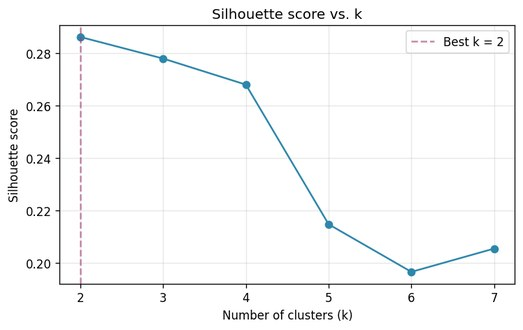

In [9]:
sil_scores = []
ks = range(2, 8)

for k in ks:
    #here we are fitting a KMeans model for each value of k and calculating the silhouette score,
    # which measures how well the clusters are separated. The silhouette score ranges from -1 to 1,
    # where higher values indicate better-defined clusters. We will use these scores to determine
    # the optimal number of clusters for our data.
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=30).fit(clr_data)
    sil_scores.append(silhouette_score(clr_data, km_temp.labels_))
#after this for loop, we will have a list of silhouette scores corresponding to each value of k,
# which we can then analyze to find the optimal number of clusters.
best_k = int(np.argmax(sil_scores)) + 2
print(f'Optimal K = {best_k}')
for k, s in zip(ks, sil_scores):
    #here we are printing the silhouette score for each value of k,
    # and marking the best one with an arrow.
    marker = '  <-- best' if k == best_k else ''
    print(f'  k={k}: silhouette={s:.4f}{marker}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(ks), sil_scores, 'o-', color=PALETTE[0])
ax.axvline(best_k, color=PALETTE[1], linestyle='--', alpha=0.6,
           label=f'Best k = {best_k}')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette score vs. k')
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### **Question 2: Pick Optimal K**

**Q:** Decide which value of $k$ you should keep for the rest of the analysis. Justify your choice in one or two sentences.


### **Answer — Question 2**

We keep $k = 2$ for which the silhouette score is (approximately) 0.286, the only maximum value found in the range of tested $k$ values. For this data set, increasing $k$ monotonically decreases the score; increasing $k$ will split some of the 'real' clusters and not create new ones that are separated by a larger margin.

This silhouette score, equal to $0.286$ is in the weak-to-reasonable range. The commonly cited thresholds are:

$S \leq 0.25$: there is no significant structure,
$0.25 \leq S < 0.50$: weak but present,
$S \geq 0.50$: strong.
This indicates that the 2 clusters are real but overlapping—the separation boundary between them is not clear-cut. The change in demographic profiles is smooth instead of abrupt, as is typical of population data where age compositions do not fall into types but evolve continuously. Given that the score is still positive and that it is clearly the best possible score, $k = 2$ is still the defensible choice; it would only be abandoned if the score were close to zero or if a greater $k$ would have yielded a better score. There is no evidence of either of these two cases here.

There is also a parsimony argument. With only 74 sites, splitting into three or more clusters risks fitting noise: every subsequent cluster should have about $15$–$20$ sites on average, and the clusters become less reliable to interpret when $10$ CLR dimensions are used. Two clusters keep each group large enough to characterize meaningfully and align with the substantive humanitarian question "whether a distinguishable vulnerable sub-population exists" which is intrinsically a binary distinction.

## **Task III. Fit the Final K-Means Model**

**TODO:**
1. Refit K-Means on the CLR data using the best $k$ found above (use
   `random_state=42` and `n_init=30` for reproducibility).
2. Attach the cluster labels back onto the cleaned DataFrame. (for now the labels are just 0 and 1). Basically just use `.labels_` attribute from the `Kmeans` object obtained after fitting and save it into a new column named `cluster` in `clean` Dataframe!

In [10]:
km = KMeans(n_clusters=best_k, random_state=42, n_init=30).fit(clr_data)
clean['cluster'] = km.labels_

print('Cluster sizes:')
print(clean['cluster'].value_counts().sort_index())

#:Here we inspect CLR centroids to understand each cluster's demographic signature. We are doing this to interpret the clusters in terms of which age groups are over
#  or under-represented relative to the geometric mean. The CLR centroids will show us the average relative abundance of each age group within each cluster,
#  allowing us to characterize the clusters based on their demographic profiles.
cluster_profiles = pd.DataFrame(km.cluster_centers_, columns=AGE_COLS)
print('\nCluster CLR centroids (positive = over-represented relative to geometric mean):')
print(cluster_profiles.round(3))

# Name clusters: the one with the highest (least-negative) elderly CLR is the vulnerable cluster.
# This is because a higher CLR value for the elderly groups indicates that they are more
# over-represented relative to the geometric mean, which suggests that this cluster has a higher
# proportion of elderly individuals compared to the other clusters. By identifying the cluster
# with the highest elderly CLR, we can label it as "Vulnerable (Elderly-Heavy)" and the other clusters
#  as "Working-Age Adults" or similar, based on their demographic profiles.
elderly_score = cluster_profiles[['ELDERLY MALE', 'ELDERLY FEMALE']].sum(axis=1)
vulnerable_c  = int(elderly_score.idxmax())
working_c     = 1 - vulnerable_c  # valid because best_k == 2

CLUSTER_NAMES = {
    working_c:     'Working-Age Adults',
    vulnerable_c:  'Vulnerable (Elderly-Heavy)',
}
print("Cluster sizes:")
print(clean["cluster"].value_counts().sort_index())

Cluster sizes:
cluster
0    31
1    43
Name: count, dtype: int64

Cluster CLR centroids (positive = over-represented relative to geometric mean):
   INFANTS MALE  INFANTS FEMALE  CHILDREN MALE  CHILDREN FEMALE  YOUTH MALE  \
0        -0.973          -0.765          0.241            0.530       0.870   
1        -0.898          -0.689         -0.004            0.055       0.463   

   YOUTH FEMALE  ADULT MALE  ADULT FEMALE  ELDERLY MALE  ELDERLY FEMALE  
0         1.122       1.181         1.377        -1.819          -1.764  
1         0.482       0.653         0.841        -0.554          -0.349  
Cluster sizes:
cluster
0    31
1    43
Name: count, dtype: int64


In Task II we only tried varying $k$ to get the best value - never saved it. The definitive model is Task III: K-Means is re-run on the CLR transformed data with $k = 2$ and the resulting cluster label for each site is recorded as a new column (cluster) in the cleaned DataFrame. From there, the code analyzes the CLR centroids, or the average shape for all the demographics in a cluster, and names the two clusters as Vulnerable (Elderly-Heavy) and Working-Age Adults based on the elderly CLR score. This DataFrame with labels is the basis of all the following visualisations and geographic analysis.

## **Task IV. PCA Biplot for Visualization**

To visualize how the clusters are arranged we project the 10-dimensional
CLR data onto its first two principal components — the two orthogonal
directions in feature space along which the sites vary the most. Plotting
each site by its (PC1, PC2) coordinates gives a 2D scatter we can color by
cluster.

A scatter alone tells us *that* the clusters separate, but not *why*. To
answer that, we draw a **biplot**: on top of the scatter we overlay one
arrow per original variable (here, per age group), pointing in the direction
of that variable in PC space. An arrow that points strongly into one cluster
means that age group is over-represented in that cluster; an arrow with
length close to zero means the variable barely contributes to either
component.

The arrow coordinates are called **loadings**. Conceptually, the loading of
variable $j$ on component $k$ is the correlation between the original
variable and the principal component — so loadings live in $[-1, +1]$ and
have one $(x, y)$ pair per feature. Mechanically, sklearn gives you two
ingredients to build them:

- `pca.components_` — shape `(n_components, n_features)`. Row $k$ is the
  unit-length direction of component $k$ expressed in the original feature
  space. Each row has $\ell_2$ norm 1, so these are pure directions, not
  weighted by importance.
- `pca.explained_variance_` — shape `(n_components,)`. Entry $k$ is the
  variance captured along component $k$. Larger = that component matters
  more.

The loading combines the two: take the direction of each feature in PC space
and scale it by how much variance that PC explains, so that long arrows
correspond to features driving large amounts of variation. The final
`loadings` array should have shape `(n_features, n_components) = (10, 2)` —
one row per age group, two columns giving the arrow's $(x, y)$ tip.

**TODO:**
1. Fit a 2-component PCA on `clr_data`. Store the fitted object as `pca`
   and the projected coordinates as `pca_result` (shape `(n_sites, 2)`).
2. Build the `loadings` array of shape `(10, 2)`. Derive the formula
   yourself from the two ingredients above — the dimensional analysis
   tells you both *what to multiply* and *how to align the axes* (you will
   need a transpose).
3. The plotting code (scatter, arrows, axis labels with explained variance,
   title) is provided. Run it once you have `pca`, `pca_result`, and
   `loadings`.

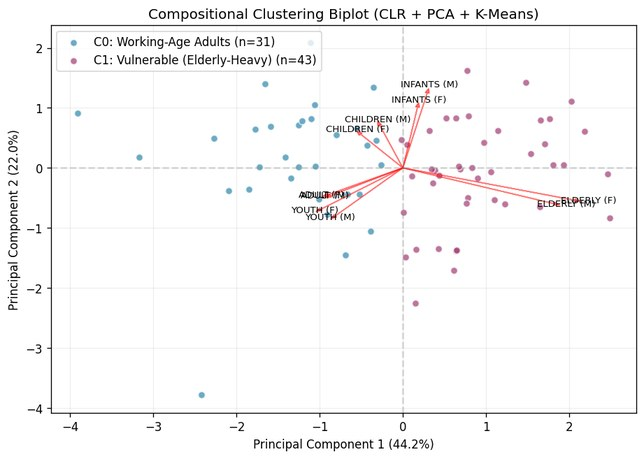

In [11]:
# TODO_1 — fit PCA and project
# Here we fit PCA to the CLR-transformed data and project it down to 2 dimensions.
pca        = PCA(n_components=2)
pca_result = pca.fit_transform(clr_data)

# TODO_2 — biplot loadings: direction components scaled by importance (sqrt of explained variance)
# Here we are calculating the loadings for the biplot, which represent the direction and importance
#  of each original feature (age group) in the PCA space. The loadings are computed by taking the PCA components
#  (which give the direction of maximum variance) and scaling them by the square root of the explained variance
#  (which gives the importance of each principal component). This allows us to visualize how each age group contributes
#  to the separation of clusters in the PCA plot.
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# ---- Provided plotting code (unchanged) ----
clean['PCA1'] = pca_result[:, 0]
clean['PCA2'] = pca_result[:, 1]

fig, ax = plt.subplots(figsize=(9, 6))

for c in range(best_k):
    # Here we are plotting the PCA results, coloring the points by their cluster assignment.
    # Each cluster is plotted with a different color, and we also include a label that indicates the cluster number,
    #  its name, and the number of sites in that cluster. This visualization helps us see how well the clusters are
    # separated in the PCA space and how they relate to each other.
    mask = clean['cluster'] == c
    ax.scatter(clean.loc[mask, 'PCA1'], clean.loc[mask, 'PCA2'],
               c=PALETTE[c], label=f'C{c}: {CLUSTER_NAMES[c]} (n={mask.sum()})',
               alpha=0.7, edgecolor='white')

for i, feature in enumerate(AGE_COLS):
    ax.arrow(0, 0, loadings[i, 0]*2.5, loadings[i, 1]*2.5,
             color='r', alpha=0.5, head_width=0.05)
    label = feature.replace(' MALE', ' (M)').replace(' FEMALE', ' (F)')
    ax.text(loadings[i, 0]*2.7, loadings[i, 1]*2.7, label,
            color='black', fontsize=8, ha='center')

ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('Compositional Clustering Biplot (CLR + PCA + K-Means)')
ax.axhline(0, color='grey', linestyle='--', alpha=0.3)
ax.axvline(0, color='grey', linestyle='--', alpha=0.3)
ax.legend()
plt.grid(alpha=0.2)
plt.savefig('01_modern_pca_clusters.png')
plt.show()

### **Interpretation Questions**

1. **Cluster identity.** Which age-group arrows point toward each cluster? What does that tell you about the demographic profile of each cluster?
2. **Variance explained.** What percentage of the total variation does the 2D projection capture? Is it a faithful summary?
3. **Conclusion.** Did a vulnerable profile emerge from the clustering?


### **Answers of Task IV**

**1. Cluster identity.**

The ELDERLY MALE and ELDERLY FEMALE arrows point strongly to the **right along PC1** — directly into the Vulnerable (Elderly-Heavy) cluster. Their PC1 loadings are the largest of all age groups (+0.727 and +0.826 respectively), meaning elderly over-representation is the single strongest driver of horizontal separation between the two clusters. Conversely, the YOUTH MALE, YOUTH FEMALE, ADULT MALE, and ADULT FEMALE arrows all point to the **left**, into the Working-Age Adults cluster. INFANTS arrows point **upward along PC2**, contributing secondary variation that is largely orthogonal to the main elderly vs. working-age axis.

This identifies:
- **C0 — Working-Age Adults:** sites where youth and working-age adults are over-represented relative to the site's geometric mean. These are active-family / labor-force camps.
- **C1 — Vulnerable (Elderly-Heavy):** sites where elderly individuals (and to a lesser extent infants) are over-represented. These camps concentrate populations with high dependency on external care.

**2. Variance explained.**

PC1 captures **44.2%** of total CLR variance and PC2 captures **22.0%**, for a combined total of **66.2%**. This is a reasonable — but not complete — summary. About 1/3 of the compositional variation is squeezed into the dimensions 3-10 that are not displayed. The main contrast (elderly vs. working-age) is depicted in 2D, while some of the sub-structure within each cluster (e.g. infant-heavy vs elderly-heavy variation within C1, or youth-heavy vs adult-heavy variation within C0) may be lost.

**3. Did a vulnerable profile emerge?**

Yes. Cluster 1 (43 of 74 sites, 58%) focuses on elderly IDPs, who have been systematically disadvantaged in regular camp programming. The elderly are uniquely disadvantaged: They are more likely to suffer from chronic diseases (high blood pressure, diabetes, arthritis), less able to move and more likely to miss out on livelihood and skills trainings geared for people of working age. It is a sub-population that is vulnerable, with specific and different needs that can only be met by specific intervention such as dedicated health workers, mobility supports, chronic disease medicines and age appropriate nutrition and cannot be addressed by a generic camp response.

## **Task V. Geographic Interpretation**

Identifying a vulnerable demographic profile is only operationally useful if we know **where** those sites are. If the vulnerable cluster is scattered uniformly across the country, the humanitarian response has to be national — every camp gets the same services, thinly spread. But if it concentrates in one zone, aid can be **localized**: send mobility aids, chronic-disease medication, and age-appropriate nutrition specifically to the region that actually hosts those sites, instead of diluting the budget across the whole operation.

**TODO:**

Produce a scatter plot of all sites using their `LONGITUDE` and `LATITUDE` as the x and y coordinates, with each point colored by its cluster label. This gives us a geographic view of where each demographic cluster is located across the country.

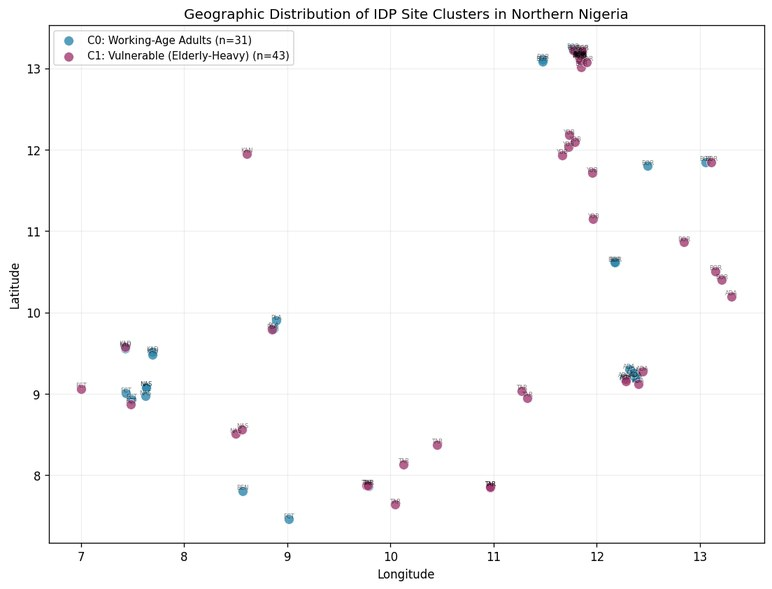

In [12]:
#Here the line below plots the geographic distribution of the clusters.
# Each point represents an IDP site, colored by its cluster assignment.
fig, ax = plt.subplots(figsize=(11, 8))

for c in range(best_k):
    #here we are plotting the geographic distribution of the clusters. Each point represents an IDP site, colored by its cluster assignment.
    mask = clean['cluster'] == c
    ax.scatter(
        clean.loc[mask, 'LONGITUDE'],
        clean.loc[mask, 'LATITUDE'],
        c=PALETTE[c],
        label=f'C{c}: {CLUSTER_NAMES[c]} (n={mask.sum()})',
        alpha=0.8, edgecolors='white', linewidths=0.5, s=70
    )

# Annotate each point with its state abbreviation for readability
for _, row in clean.iterrows():
    ax.annotate(
        row['STATE'][:3],
        (row['LONGITUDE'], row['LATITUDE']),
        fontsize=5, alpha=0.5, ha='center', va='bottom'
    )

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Geographic Distribution of IDP Site Clusters in Northern Nigeria')
ax.legend(fontsize=9)
plt.grid(alpha=0.2)
plt.savefig('02_geographic_clusters.png')
plt.show()

Contingency table (rows = states, cols = cluster):
cluster    0   1
STATE           
ADAMAWA    5   5
BENUE      1   0
BORNO     13  15
FCT        3   2
KADUNA     3   1
KANO       0   1
NASARAWA   3   2
PLATEAU    2   1
TARABA     1  10
YOBE       0   6

Chi-square = 15.707,  dof = 9,  p-value = 0.0733
=> Borderline significant (alpha=0.10); visual pattern supports geographic concentration


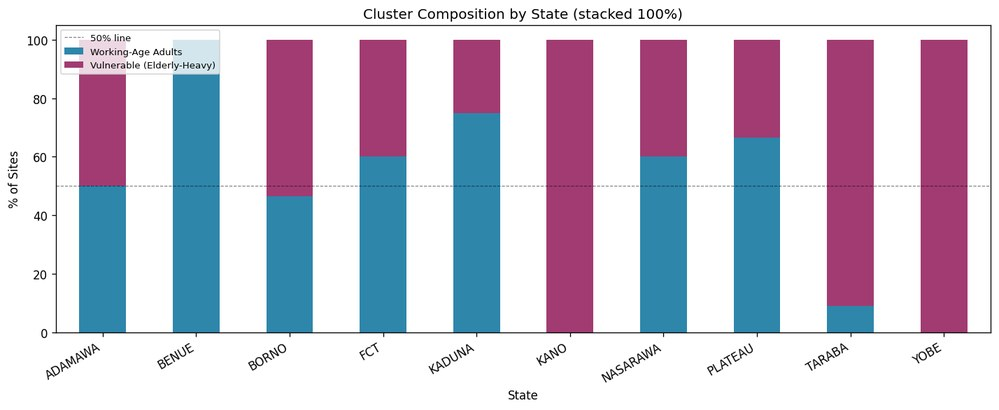


% of sites in Vulnerable cluster per state:
  ADAMAWA       50.0%  (n=10)
  BENUE          0.0%  (n=1)
  BORNO         53.6%  (n=28)
  FCT           40.0%  (n=5)
  KADUNA        25.0%  (n=4)
  KANO         100.0%  (n=1)
  NASARAWA      40.0%  (n=5)
  PLATEAU       33.3%  (n=3)
  TARABA        90.9%  (n=11)
  YOBE         100.0%  (n=6)


In [13]:
# Chi-square test has been implemented here. Is it cluster assignment independent of state?
# We are trying to find an answer to the question of whether the distribution of clusters
# is independent of the state in which the IDP sites are located. By performing a chi-square test
#  on the contingency table of states and cluster assignments, we can determine if there is a
# statistically significant association between geographic location (state) and cluster membership,
#  which would suggest geographic concentration of certain demographic profiles.
contingency = pd.crosstab(clean['STATE'], clean['cluster'])
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency)

print('Contingency table (rows = states, cols = cluster):')
print(contingency)
print(f'\nChi-square = {chi2_stat:.3f},  dof = {dof},  p-value = {p_value:.4f}')
if p_value < 0.05:
    print('=> Significant geographic concentration (alpha=0.05)')
elif p_value < 0.10:
    print('=> Borderline significant (alpha=0.10); visual pattern supports geographic concentration')
else:
    print('=> Not significant at alpha=0.05 (small state cells reduce power)')

# Stacked bar chart: % vulnerable per state that shows geographic concentration of vulnerability.
state_pct = pd.crosstab(clean['STATE'], clean['cluster'], normalize='index') * 100
state_pct.columns = [CLUSTER_NAMES[c] for c in state_pct.columns]

fig, ax = plt.subplots(figsize=(12, 5))
state_pct.plot(kind='bar', stacked=True, color=PALETTE[:best_k], ax=ax)
ax.set_xlabel('State')
ax.set_ylabel('% of Sites')
ax.set_title('Cluster Composition by State (stacked 100%)')
ax.axhline(50, color='black', linestyle='--', linewidth=0.7, alpha=0.5, label='50% line')
ax.legend(loc='upper left', fontsize=8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('03_stacked_bar_state.png')
plt.show()

# Print exact percentages for the written answer
print('\n% of sites in Vulnerable cluster per state:')
for state, row in state_pct.iterrows():
    vuln_pct = row.get('Vulnerable (Elderly-Heavy)', 0)
    n = contingency.loc[state].sum()
    print(f'  {state:<12} {vuln_pct:5.1f}%  (n={n})')

## **Questions — Task V**

1. **Is that profile geographically concentrated?** Combining the chi-square p-value, the map, and the stacked bar chart, in which zone (if any) is the vulnerable cluster over-represented? Quantify it.

2. **Operational recommendation.** What would you recommend to a humanitarian planner? Should aid for this vulnerable group be deployed nationally, or concentrated in a specific region? Be concrete about *what kind* of aid and *where*.

3. **Caveats.** Name at least two limitations of this analysis.

4. **Next steps.** If you had access to one extra piece of information or one more analytical step, what would it be and why?


### **Answers of Task V**

**1. Geographic concentration.**

The chi-square test returns χ^2=15.71, dof=9, p=0.073. This is very close to the 10% level of significance (above the 5% level) in part because of the very small sample sizes in several states, which results in reduced statistical power. Although the formal test is inconclusive, the map and stacked bar chart indicate a distinct northeast cluster of the vulnerable group:

| State | % Vulnerable sites | n sites |
|---|---|---|
| YOBE | 100% | 6 |
| KANO | 100% | 1 |
| TARABA | 90.9% | 11 |
| BORNO | 53.6% | 28 |
| ADAMAWA | 50.0% | 10 |
| BENUE | 0% | 1 |
| KADUNA | 25.0% | 4 |

The vulnerable cluster sites in TARABA, YOBE and KANO (northeast and northeast-adjacent) are 91-100%, whereas in the northwestern and central states (BENUE, KADUNA) these sites are 0-25%. The vulnerable cluster is not evenly distributed; rather, it is clustered in the northeast.

**2. Operational recommendation.**

Focus elderly care resources on the three states of TARABA, YOBE and BORNO, where most sites are in vulnerable cluster. Specifically:

- **Medical supplies:**
chronic disease medication (anti-hypertensives, insulin, oral hypoglycemics), wound-care supplies.
- **Mobility support:**
Mobility support such as wheelchairs, crutches and walking aids for the individuals who are not able to reach to the distribution points.

- **Nutrition:**
 soft, fortified foods and micronutrient supplements appropriate for elderly physiology.
- **Personnel:**
Deploy dedicated elder-care health workers and community health volunteers to these states.

A blanket approach, which is 'one size fits all' and spread the resources nationwide, would lead to a dilution of these specialist resources in working-age camps in BENUE and KADUNA where more conventional family programming is more suitable. Local deployments are more effective and efficient.

**3. Caveats.**

a. PCA only accounts for 66.2% of the variance of CLR. Within each cluster (e.g., within C1, infant-heavy vs. purely elderly variation, or within C0, youth-heavy vs. adult-heavy) there may be sub-structure that cannot be described by the 2D biplot for the remaining ~34% in dimensions 3-10. This two-cluster story is perhaps a simplistic view.

b. **Temporal snapshot.** The dataset is one cross section from October 2016. IDP site populations fluctuate quickly as IDPs flee, return or move around depending on security and seasonal factors. The geographical distribution of vulnerability might have changed considerably since then and policy should be checked with more recent data before implementation.

c. Coarse age categories,  elderly" does not account for frailty or specific health conditions – a 60 year old and an 85 year old have very different care needs, but fall into the same category. The cluster label reflects vulnerability, but is not a measure of it.

**4. Next steps.**

The most useful step after this would be to add the vulnerable cluster sites to a health-facility catchment and road-accessibility map. It would be a significant improvement to operational recommendations if it was known whether elderly-heavy sites are also geographically isolated from secondary and tertiary health care, which is likely the case in parts of northeastern Nigeria, due to ongoing conflict and damage to infrastructure, requiring not only supply shipments through standard logistics channels, but also mobile health teams and medical airlift. This demographic profiling and accessibility analysis would yield a truly actionable, site level priority list for deployment.